# Imports

In [1]:
import pandas as pd 
import numpy as np 

# for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn tools 
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split 

# 3 classifiers 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 

# evaluate 
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
df = pd.read_csv("Crop_recommendation.csv")
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


#  Exploratory Data Analysis

In [3]:
df.shape

(2200, 8)

In [4]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [8]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [9]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [10]:
df.count()

N              2200
P              2200
K              2200
temperature    2200
humidity       2200
ph             2200
rainfall       2200
label          2200
dtype: int64

In [11]:
df.max()

N                     140
P                     145
K                     205
temperature     43.675493
humidity        99.981876
ph               9.935091
rainfall       298.560117
label          watermelon
dtype: object

In [12]:
df.min()

N                      0
P                      5
K                      5
temperature     8.825675
humidity        14.25804
ph              3.504752
rainfall       20.211267
label              apple
dtype: object

# Data visualization 

In [13]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

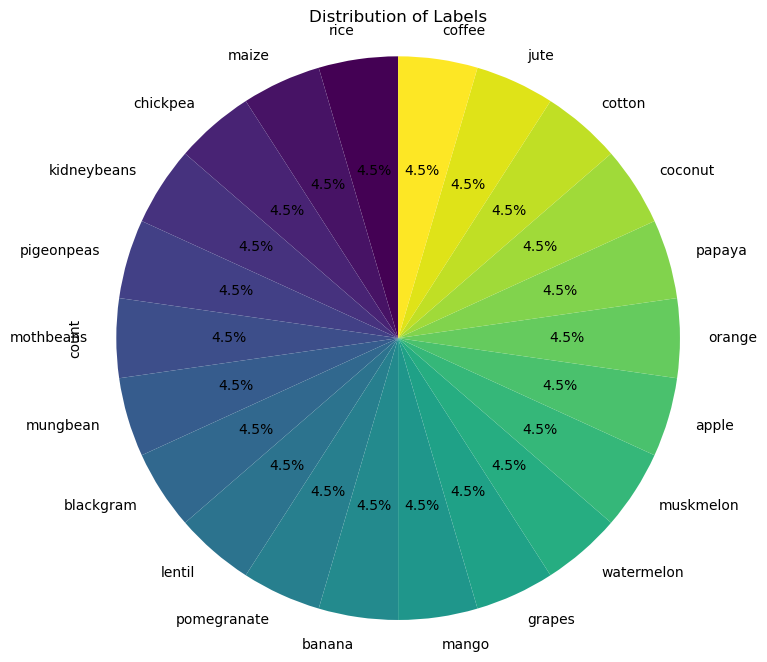

In [14]:
# Calculate the value counts for the 'label' column
label_counts = df['label'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8)) # Set the figure size for better visualization
label_counts.plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')

# Add a title to the chart
plt.title('Distribution of Labels')

# Ensure the pie chart is circular
plt.axis('equal')

# Display the chart
plt.show()

## Average N Requirement (per crop)

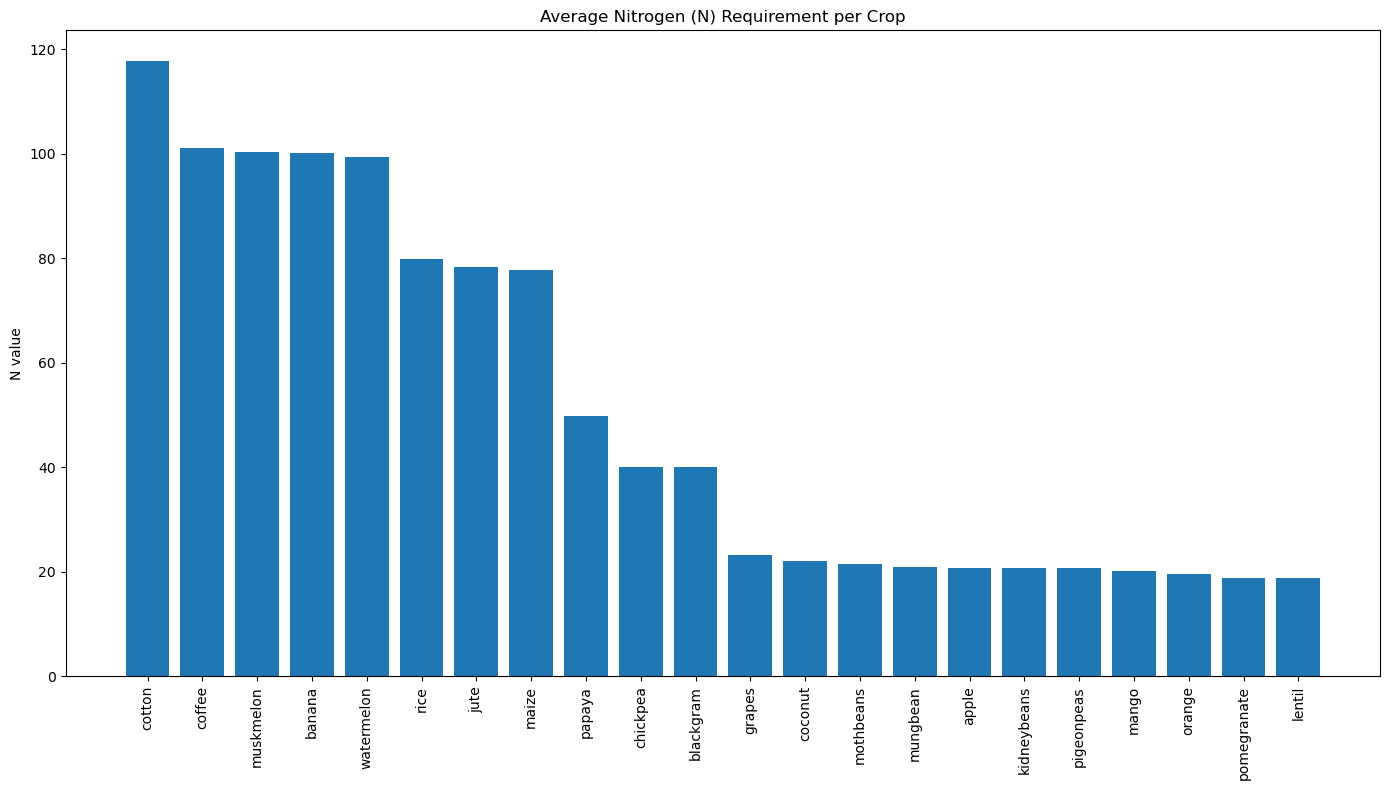

Top 5 crops (highest N):
label
cotton        117.77
coffee        101.20
muskmelon     100.32
banana        100.23
watermelon     99.42
Name: N, dtype: float64

Bottom 5 crops (lowest N):
label
pigeonpeas     20.73
mango          20.07
orange         19.58
pomegranate    18.87
lentil         18.77
Name: N, dtype: float64


In [15]:
# Average N values for each crop
N_avg = df.groupby('label')['N'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))
plt.bar(N_avg.index, N_avg.values)

plt.title("Average Nitrogen (N) Requirement per Crop")
plt.ylabel("N value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Top 5 crops (highest N):")
print(N_avg.head())

print("\nBottom 5 crops (lowest N):")
print(N_avg.tail())


## Average P Requirement (per crop)

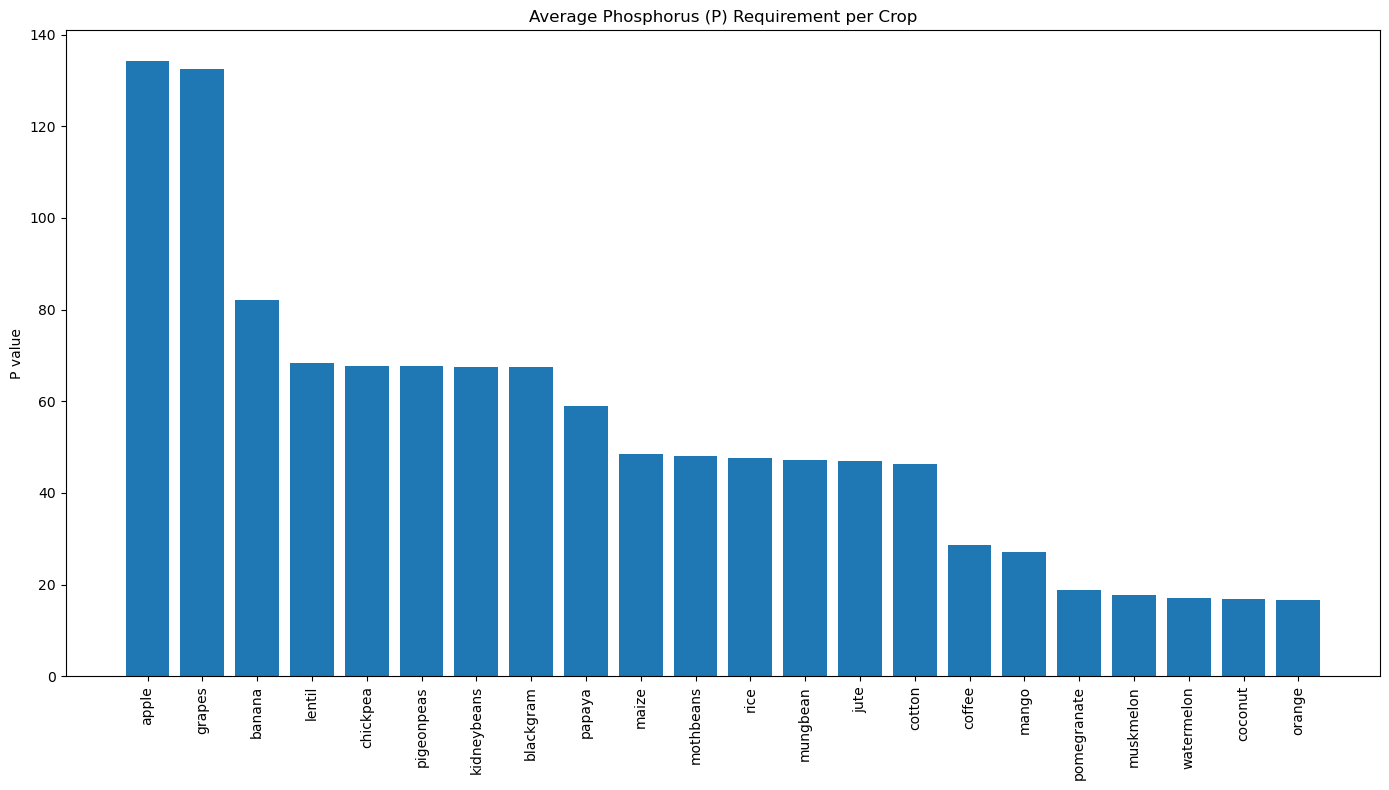

Top 5 crops (highest P):
label
apple       134.22
grapes      132.53
banana       82.01
lentil       68.36
chickpea     67.79
Name: P, dtype: float64

Bottom 5 crops (lowest P):
label
pomegranate    18.75
muskmelon      17.72
watermelon     17.00
coconut        16.93
orange         16.55
Name: P, dtype: float64


In [16]:
P_avg = df.groupby('label')['P'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))
plt.bar(P_avg.index, P_avg.values)

plt.title("Average Phosphorus (P) Requirement per Crop")
plt.ylabel("P value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Top 5 crops (highest P):")
print(P_avg.head())

print("\nBottom 5 crops (lowest P):")
print(P_avg.tail())


## Average K Requirement (per crop)

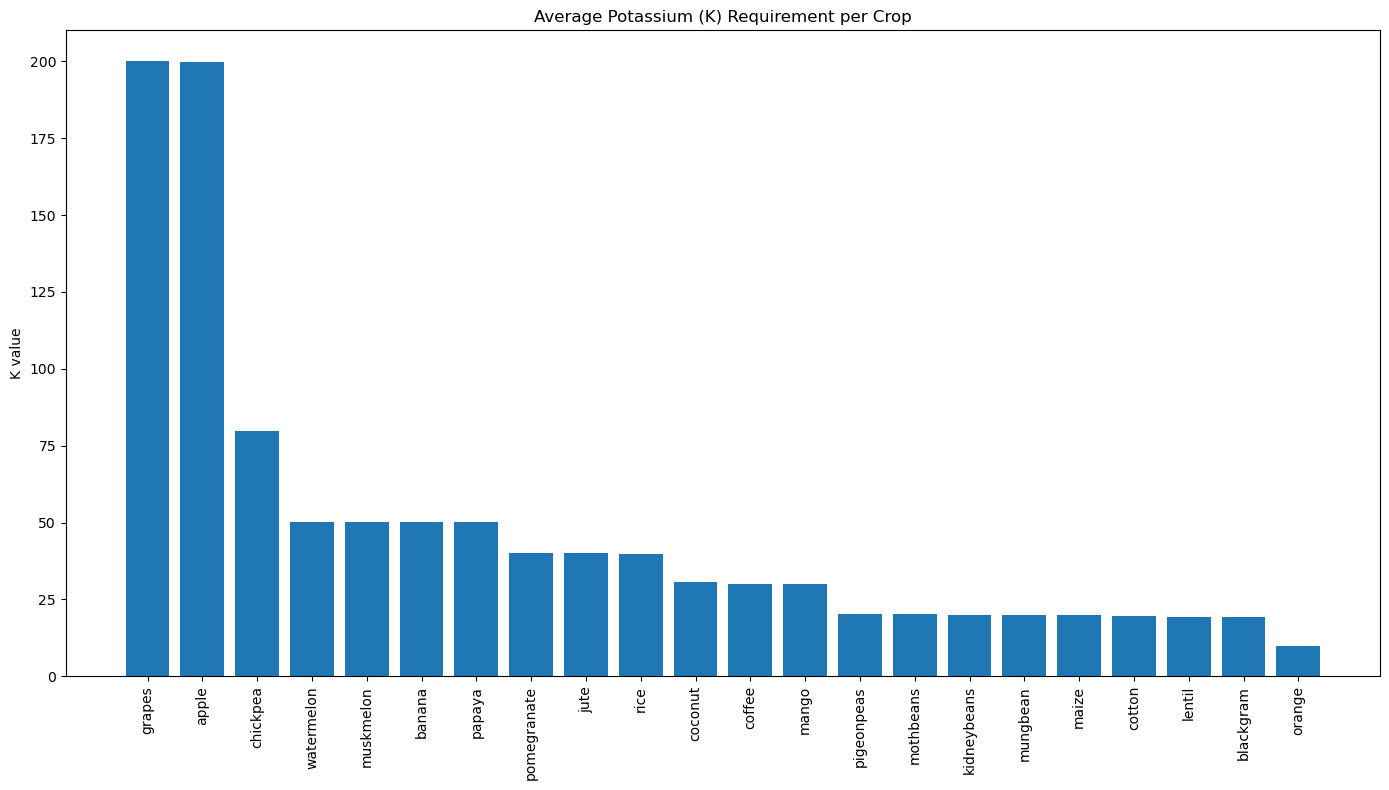

Top 5 crops (highest K):
label
grapes        200.11
apple         199.89
chickpea       79.92
watermelon     50.22
muskmelon      50.08
Name: K, dtype: float64

Bottom 5 crops (lowest K):
label
maize        19.79
cotton       19.56
lentil       19.41
blackgram    19.24
orange       10.01
Name: K, dtype: float64


In [17]:
K_avg = df.groupby('label')['K'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))
plt.bar(K_avg.index, K_avg.values)

plt.title("Average Potassium (K) Requirement per Crop")
plt.ylabel("K value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Top 5 crops (highest K):")
print(K_avg.head())

print("\nBottom 5 crops (lowest K):")
print(K_avg.tail())


## Average Temperature (per crop)

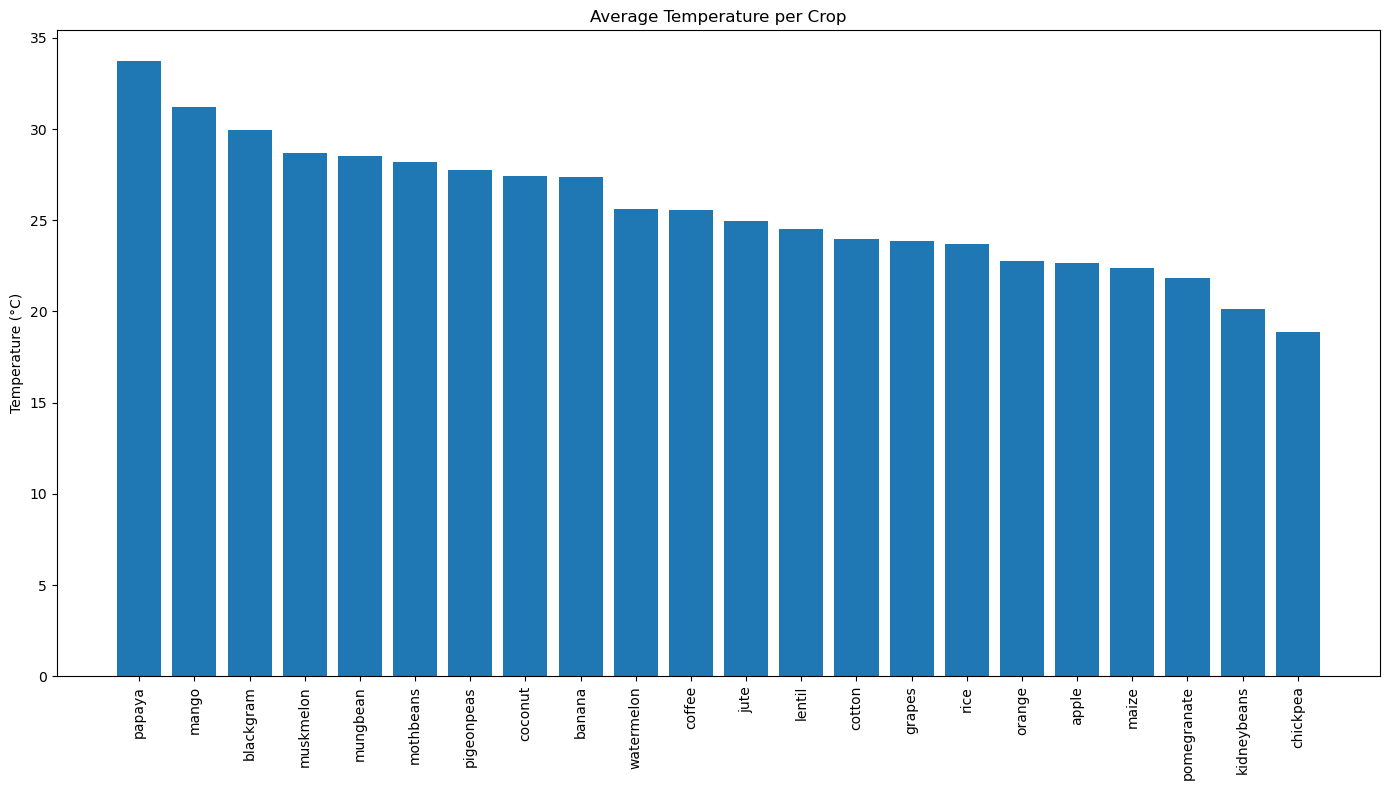

Top 5 crops (highest temperature):
label
papaya       33.723859
mango        31.208770
blackgram    29.973340
muskmelon    28.663066
mungbean     28.525775
Name: temperature, dtype: float64

Bottom 5 crops (lowest temperature):
label
apple          22.630942
maize          22.389204
pomegranate    21.837842
kidneybeans    20.115085
chickpea       18.872847
Name: temperature, dtype: float64


In [18]:
temp_avg = df.groupby('label')['temperature'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))
plt.bar(temp_avg.index, temp_avg.values)

plt.title("Average Temperature per Crop")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Top 5 crops (highest temperature):")
print(temp_avg.head())

print("\nBottom 5 crops (lowest temperature):")
print(temp_avg.tail())


## Average Humidity (per crop)

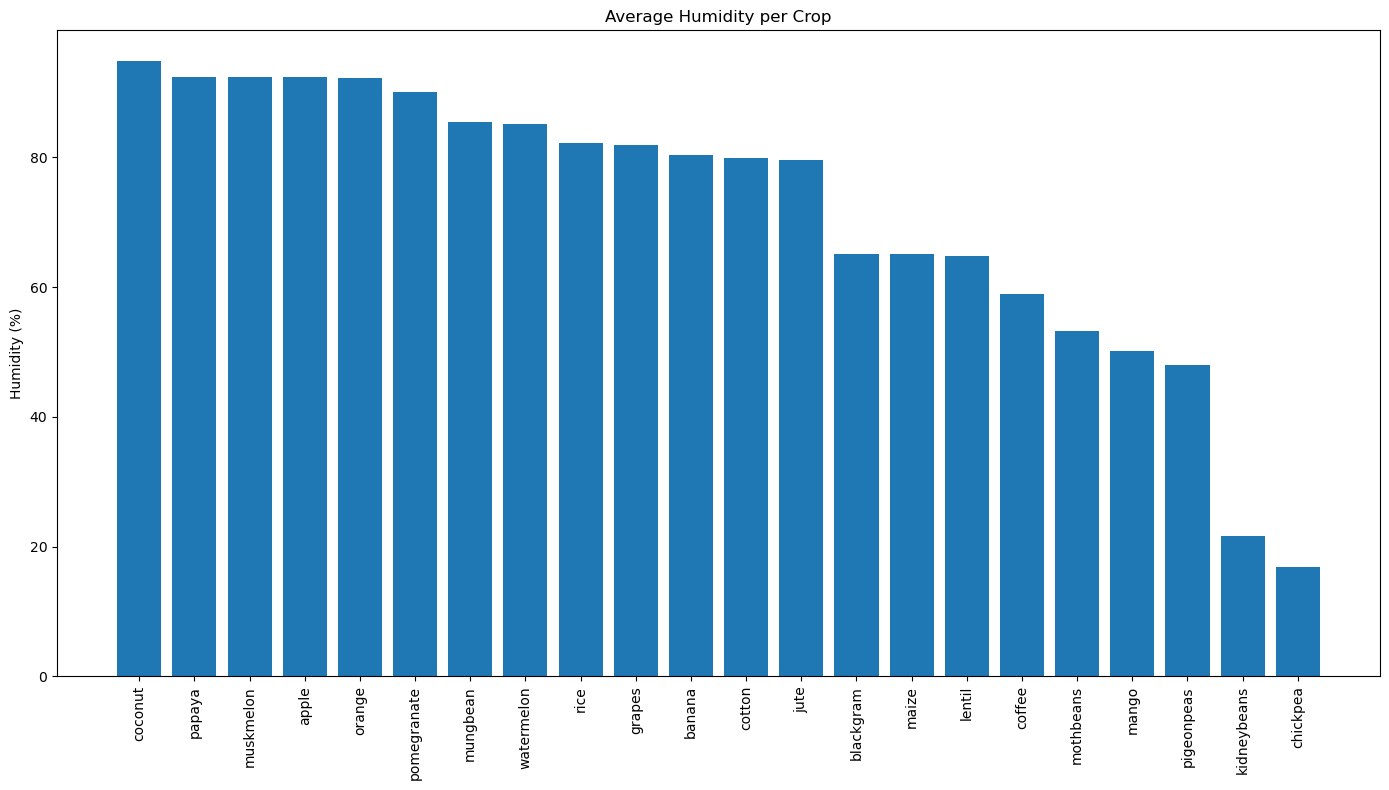

Top 5 crops (highest humidity):
label
coconut      94.844272
papaya       92.403388
muskmelon    92.342802
apple        92.333383
orange       92.170209
Name: humidity, dtype: float64

Bottom 5 crops (lowest humidity):
label
mothbeans      53.160418
mango          50.156573
pigeonpeas     48.061633
kidneybeans    21.605357
chickpea       16.860439
Name: humidity, dtype: float64


In [19]:
hum_avg = df.groupby('label')['humidity'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))
plt.bar(hum_avg.index, hum_avg.values)

plt.title("Average Humidity per Crop")
plt.ylabel("Humidity (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Top 5 crops (highest humidity):")
print(hum_avg.head())

print("\nBottom 5 crops (lowest humidity):")
print(hum_avg.tail())


## Average pH (per crop)

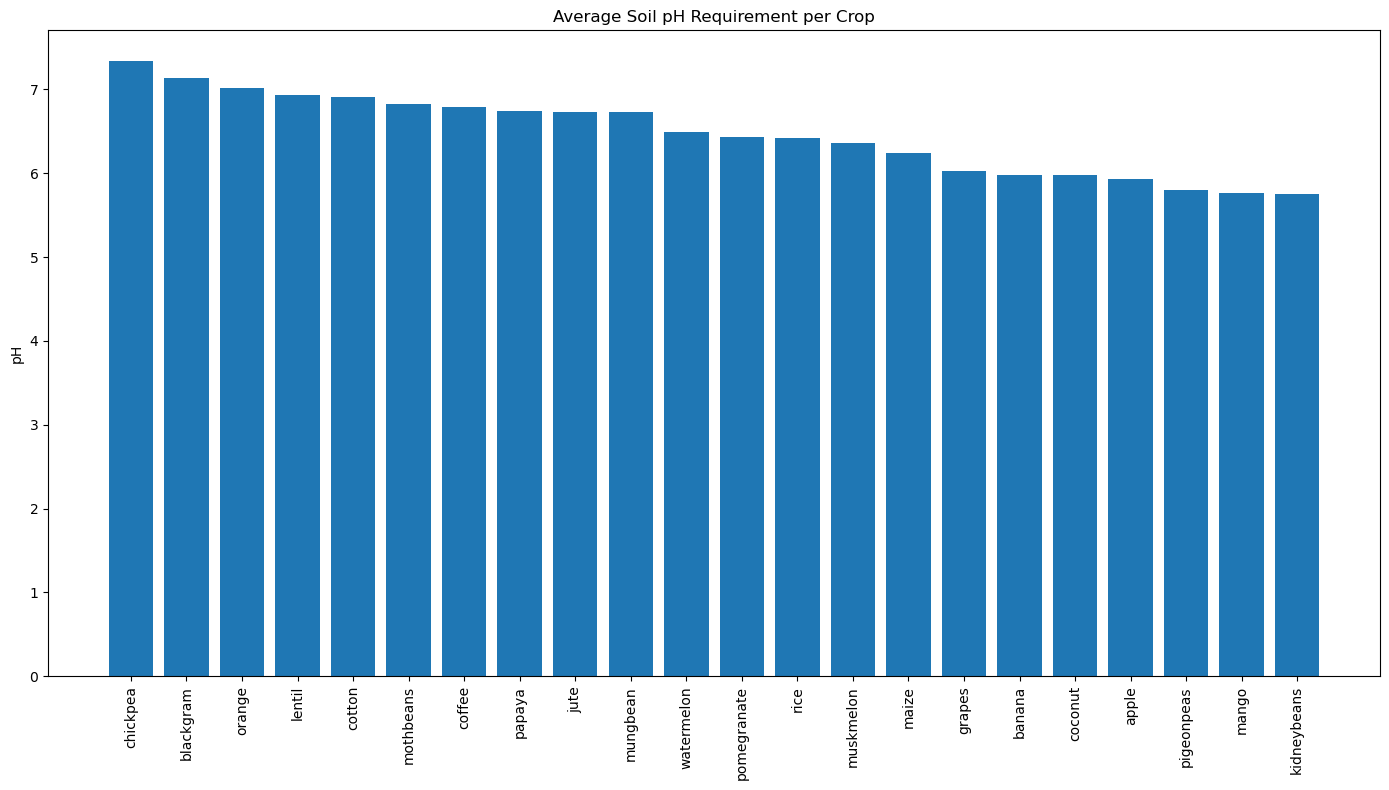

Top 5 crops (highest pH):
label
chickpea     7.336957
blackgram    7.133952
orange       7.016957
lentil       6.927932
cotton       6.912675
Name: ph, dtype: float64

Bottom 5 crops (lowest pH):
label
coconut        5.976562
apple          5.929663
pigeonpeas     5.794175
mango          5.766373
kidneybeans    5.749411
Name: ph, dtype: float64


In [20]:
ph_avg = df.groupby('label')['ph'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))
plt.bar(ph_avg.index, ph_avg.values)

plt.title("Average Soil pH Requirement per Crop")
plt.ylabel("pH")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Top 5 crops (highest pH):")
print(ph_avg.head())

print("\nBottom 5 crops (lowest pH):")
print(ph_avg.tail())


## Average Rainfall (per crop)

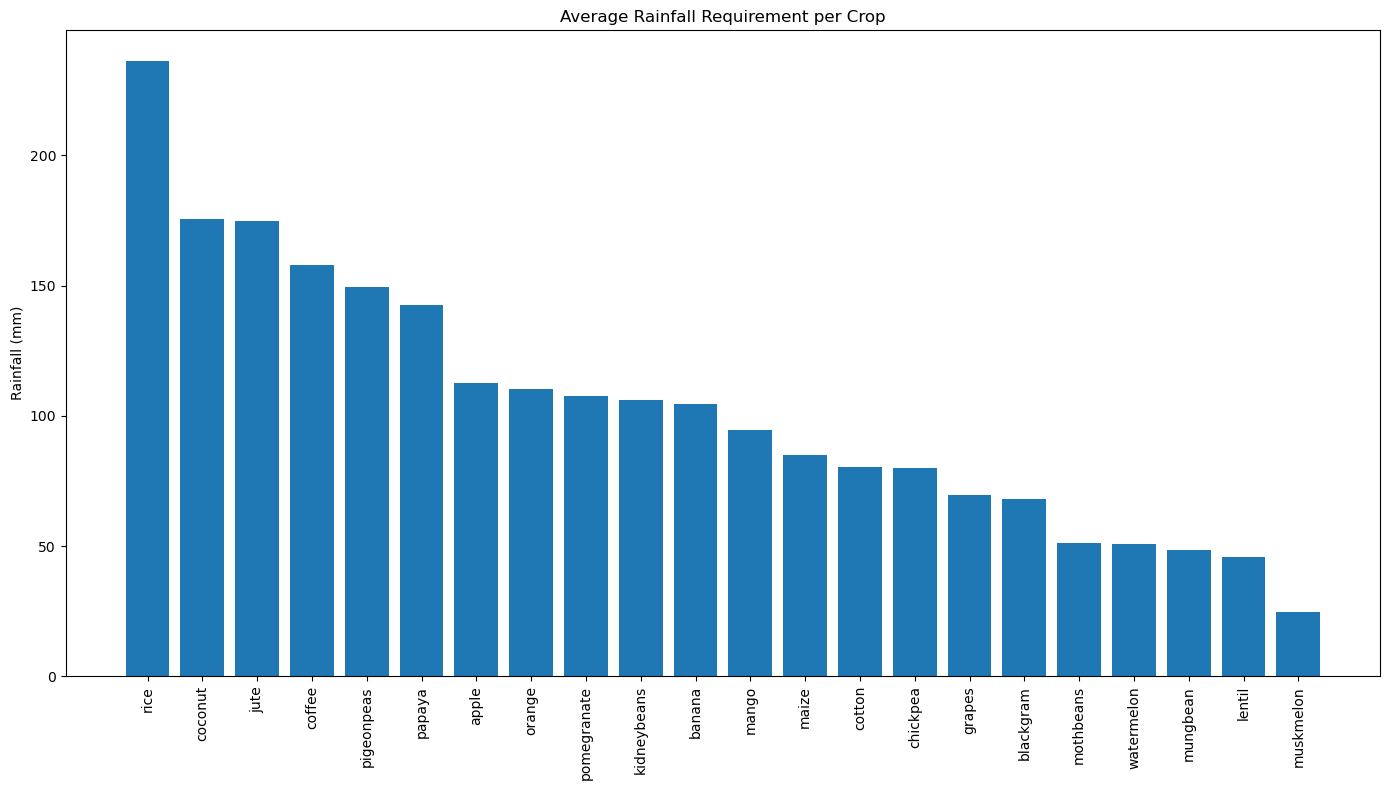

Top 5 crops (highest rainfall):
label
rice          236.181114
coconut       175.686646
jute          174.792798
coffee        158.066295
pigeonpeas    149.457564
Name: rainfall, dtype: float64

Bottom 5 crops (lowest rainfall):
label
mothbeans     51.198487
watermelon    50.786219
mungbean      48.403601
lentil        45.680454
muskmelon     24.689952
Name: rainfall, dtype: float64


In [21]:
rain_avg = df.groupby('label')['rainfall'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))
plt.bar(rain_avg.index, rain_avg.values)

plt.title("Average Rainfall Requirement per Crop")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Top 5 crops (highest rainfall):")
print(rain_avg.head())

print("\nBottom 5 crops (lowest rainfall):")
print(rain_avg.tail())


# Encoding

In [22]:
encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,5
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,5
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,5
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,5


# Scaling: Normalization

In [23]:
# Select numeric columns to normalize
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph','rainfall']

# Initialize scaler
scaler = MinMaxScaler()

# Fit-transform the numeric columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,0.642857,0.264286,0.190,0.345886,0.790267,0.466264,0.656458,20
1,0.607143,0.378571,0.180,0.371445,0.770633,0.549480,0.741675,20
2,0.428571,0.357143,0.195,0.406854,0.793977,0.674219,0.875710,20
3,0.528571,0.214286,0.175,0.506901,0.768751,0.540508,0.799905,20
4,0.557143,0.264286,0.185,0.324378,0.785626,0.641291,0.871231,20


# Train Test Split

In [24]:
X = df.drop('label',axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Training, Testing Multiple Classifiers

In [25]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest Classifier": RandomForestClassifier(),
    "Gradient Boosting Classifier": GradientBoostingClassifier(),
}


# Train and evaluate each model
for name, model in models.items():
    print("="*50)
    print("Model:", name)
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    classification_rep = classification_report(y_test, y_pred)
    
    # Print metrics
    print("Classification Report:\n", classification_rep)

    

Model: Logistic Regression
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        21
           2       0.83      0.86      0.84        22
           3       1.00      1.00      1.00        21
           4       0.88      1.00      0.93        14
           5       1.00      1.00      1.00        22
           6       0.94      1.00      0.97        15
           7       1.00      1.00      1.00        16
           8       0.93      0.76      0.84        17
           9       0.86      1.00      0.93        19
          10       0.78      0.86      0.82        21
          11       1.00      0.96      0.98        23
          12       0.52      1.00      0.69        12
          13       1.00      0.46      0.63        24
          14       0.88      1.00      0.94        22
          15       0.88      1.00      0.94        22
          16       1.00      0

# Selecting Best Model

In [26]:
model_gbc = GradientBoostingClassifier()

model_gbc.fit(X_train,y_train)

y_pred = model_gbc.predict(X_test)



print("confusion matrix \n: ", confusion_matrix(y_test,y_pred))
print("classification report \n: ", classification_report(y_test, y_pred))

confusion matrix 
:  [[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 13  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0 19  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 12  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0]
 [ 0  0  0  0

# Saving Model, Encoder, Scaler for production

In [27]:
import pickle

pickle.dump(encoder, open("models/encoder.pkl",'wb'))
pickle.dump(model_gbc,open("models/model_gbc.pkl",'wb'))
pickle.dump(scaler,open("models/scaler.pkl",'wb'))

# Inference (Prediction on new data)

In [28]:
import numpy as np

# Load encoder, scaler, and model
encoder = pickle.load(open("models/encoder.pkl", 'rb'))
scaler = pickle.load(open("models/scaler.pkl", 'rb'))  # Make sure this exists
model_gbc = pickle.load(open("models/model_gbc.pkl", 'rb'))

def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    # Create DataFrame from input values
    input_df = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]],
                            columns=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'])
    
    # Scale the data
    input_scaled = scaler.transform(input_df)
    
    # Predict and decode
    prediction_encoded = model_gbc.predict(input_scaled)
    prediction = encoder.inverse_transform(prediction_encoded)
    
    return prediction[0]


In [29]:

result = predict_crop(90, 40, 40, 25.0, 80.0, 6.5, 100.0)
print("Recommended Crop:", result)

Recommended Crop: jute


In [30]:
# Sample input values (at least 10 different sets)
test_inputs = [
    (90, 40, 40, 25.0, 80.0, 6.5, 100.0),
    (60, 30, 20, 22.5, 75.0, 6.0, 120.0),
    (80, 60, 50, 27.0, 82.0, 6.8, 95.0),
    (100, 45, 45, 30.0, 85.0, 7.0, 110.0),
    (70, 55, 65, 28.0, 78.0, 6.4, 105.0),
    (65, 40, 50, 26.0, 70.0, 5.8, 90.0),
    (55, 20, 25, 24.0, 72.0, 6.3, 130.0),
    (85, 65, 60, 29.0, 90.0, 6.7, 115.0),
    (95, 50, 70, 31.0, 88.0, 6.9, 102.0),
    (50, 25, 30, 23.0, 68.0, 6.1, 85.0)
]

# Loop through inputs and print predictions
for i, values in enumerate(test_inputs, 1):
    result = predict_crop(*values)
    print(f"{i}. Input: {values} -> Recommended Crop: {result}")

1. Input: (90, 40, 40, 25.0, 80.0, 6.5, 100.0) -> Recommended Crop: jute
2. Input: (60, 30, 20, 22.5, 75.0, 6.0, 120.0) -> Recommended Crop: maize
3. Input: (80, 60, 50, 27.0, 82.0, 6.8, 95.0) -> Recommended Crop: jute
4. Input: (100, 45, 45, 30.0, 85.0, 7.0, 110.0) -> Recommended Crop: jute
5. Input: (70, 55, 65, 28.0, 78.0, 6.4, 105.0) -> Recommended Crop: jute
6. Input: (65, 40, 50, 26.0, 70.0, 5.8, 90.0) -> Recommended Crop: maize
7. Input: (55, 20, 25, 24.0, 72.0, 6.3, 130.0) -> Recommended Crop: pomegranate
8. Input: (85, 65, 60, 29.0, 90.0, 6.7, 115.0) -> Recommended Crop: banana
9. Input: (95, 50, 70, 31.0, 88.0, 6.9, 102.0) -> Recommended Crop: jute
10. Input: (50, 25, 30, 23.0, 68.0, 6.1, 85.0) -> Recommended Crop: pomegranate
